# Лабораторная работа №1. Линейная регрессия и факторный анализ
### Цель работы
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество

### Описание датасета 
diamonds.csv - содержит информацию о характеристиках и ценах на бриллианты.   
Датасет содержит 53 940 строк и 10 признаков столбцов  
Столбцы в датасете:  
`carat` - вес брилллианта  
`cut` - качество огранки  
`color` - цвет бриллианта  
`clarity` - чистота бриллианта   
`depth` - общая глубина  
`table` -  ширина верхней площадки относительно самой широкой точки  
`x` - длина в мм  
`y` - ширина в мм  
`z`  - глубина в мм  
Целевая переменная - `price`

### Импорты библиотек

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, make_scorer
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Первичный анализ

Загрузка датасета

In [42]:
df = pd.read_csv('diamonds.csv')
print("Размер датасета:", df.shape)
display(df.head())


Размер датасета: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [44]:
# Общая информация о данных
print("\nИнформация о датасете:")
display(df.info())

print("\nОписательная статистика числовых признаков:")
display(df.describe().T)



Информация о датасете:
<class 'pandas.DataFrame'>
Index: 53920 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53920 non-null  float64
 1   cut      53920 non-null  str    
 2   color    53920 non-null  str    
 3   clarity  53920 non-null  str    
 4   depth    53920 non-null  float64
 5   table    53920 non-null  float64
 6   price    53920 non-null  int64  
 7   x        53920 non-null  float64
 8   y        53920 non-null  float64
 9   z        53920 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.5 MB


None


Описательная статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
carat,53920.0,0.797698,0.473795,0.20,0.40,0.70,1.04,5.01
depth,53920.0,61.749514,1.432331,43.00,61.00,61.80,62.50,79.00
table,53920.0,57.456834,2.234064,43.00,56.00,57.00,59.00,95.00
price,53920.0,3930.993231,3987.280446,326.00,949.00,2401.00,5323.25,18823.00
x,53920.0,5.731627,1.119423,3.73,4.71,5.70,6.54,10.74
y,53920.0,5.734887,1.140126,3.68,4.72,5.71,6.54,58.90
z,53920.0,3.540046,0.702530,1.07,2.91,3.53,4.04,31.80


Проверка пропусков 

In [22]:
print("Количество пропусков:")
print(df.isnull().sum())

Количество пропусков:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [23]:
zero_dimensions = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]
print(f"\nКоличество строк с нулевыми размерами алмазов (x, y, z): {len(zero_dimensions)}")

df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print(f"Размер датасета после удаления аномалий: {df.shape}")



Количество строк с нулевыми размерами алмазов (x, y, z): 20
Размер датасета после удаления аномалий: (53920, 10)


### Визуализация распределений и кодирование признаков

Целевая переменная 

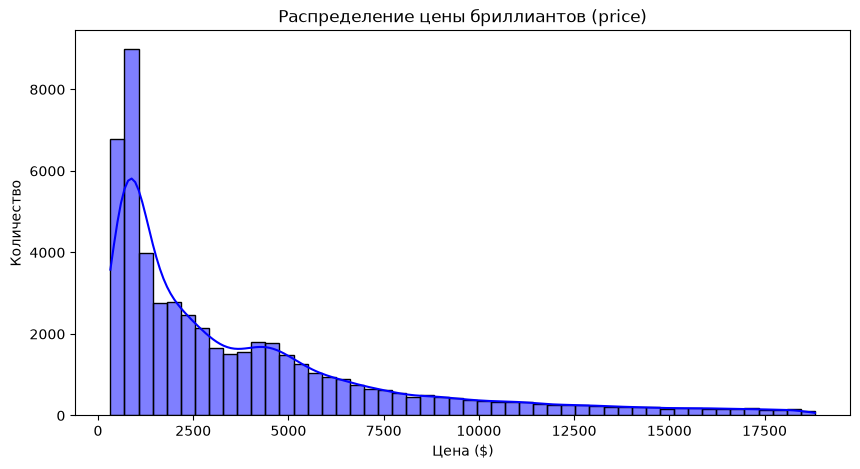

In [45]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Распределение цены бриллиантов (price)')
plt.xlabel('Цена ($)')
plt.ylabel('Количество')
plt.show()

Визуализация распределения числовых признаков

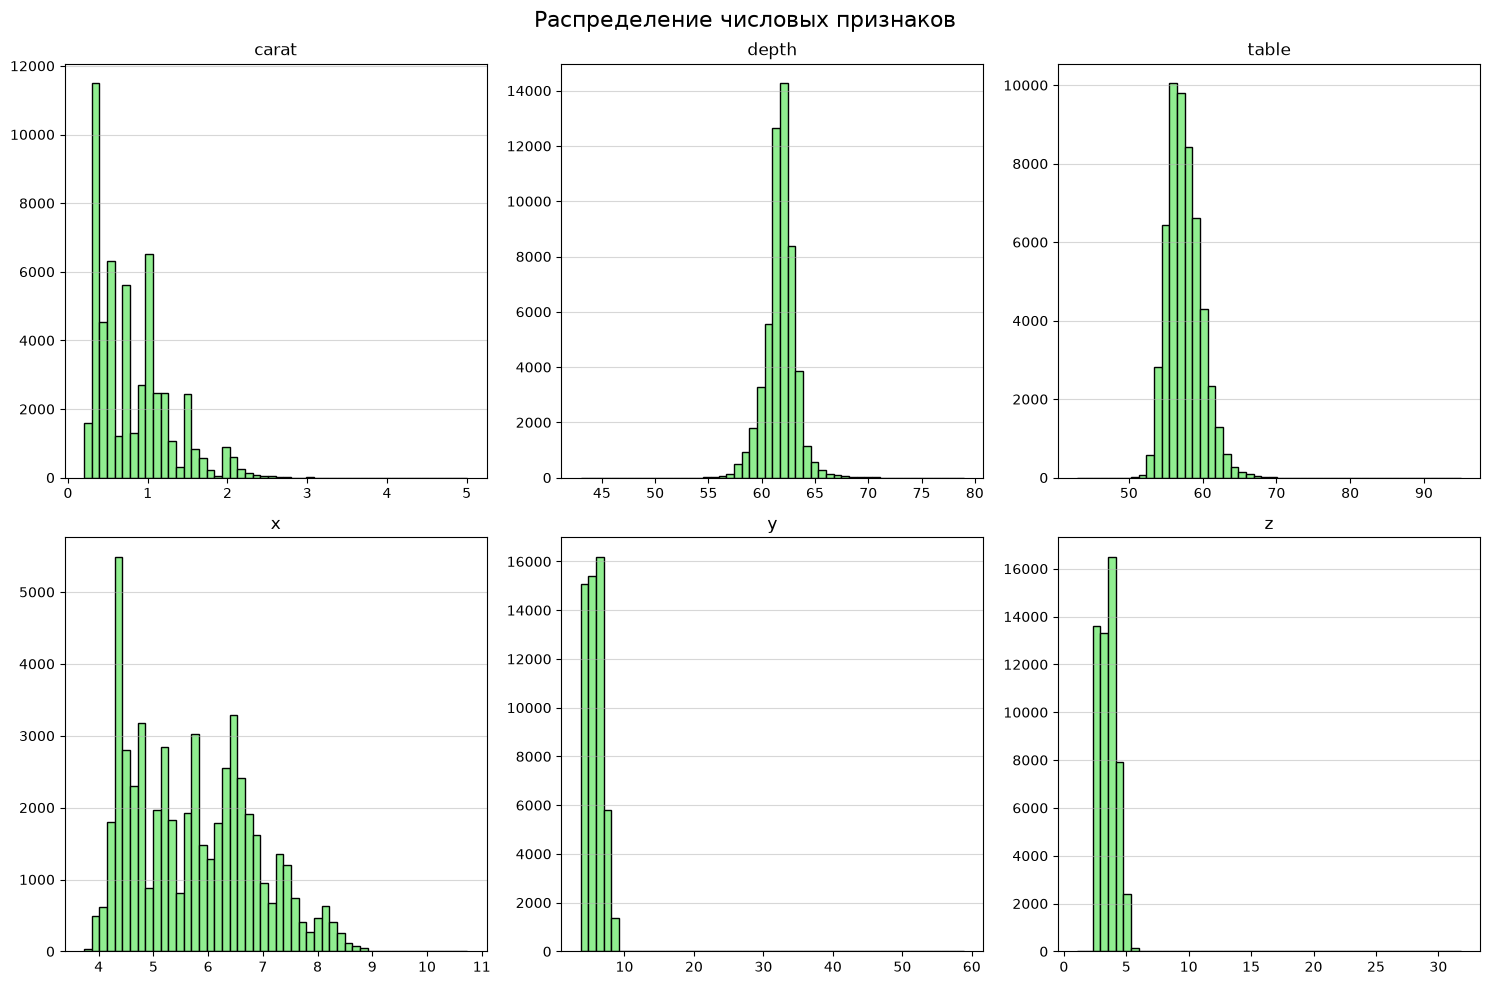

In [41]:
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Распределение числовых признаков', fontsize=16)

for i, col in enumerate(numeric_features):
    ax = axes[i//3, i%3]
    ax.hist(df[col], bins=50, color='lightgreen', edgecolor='black')
    ax.set_title(col)
    ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

Визуализация категориальных признаков

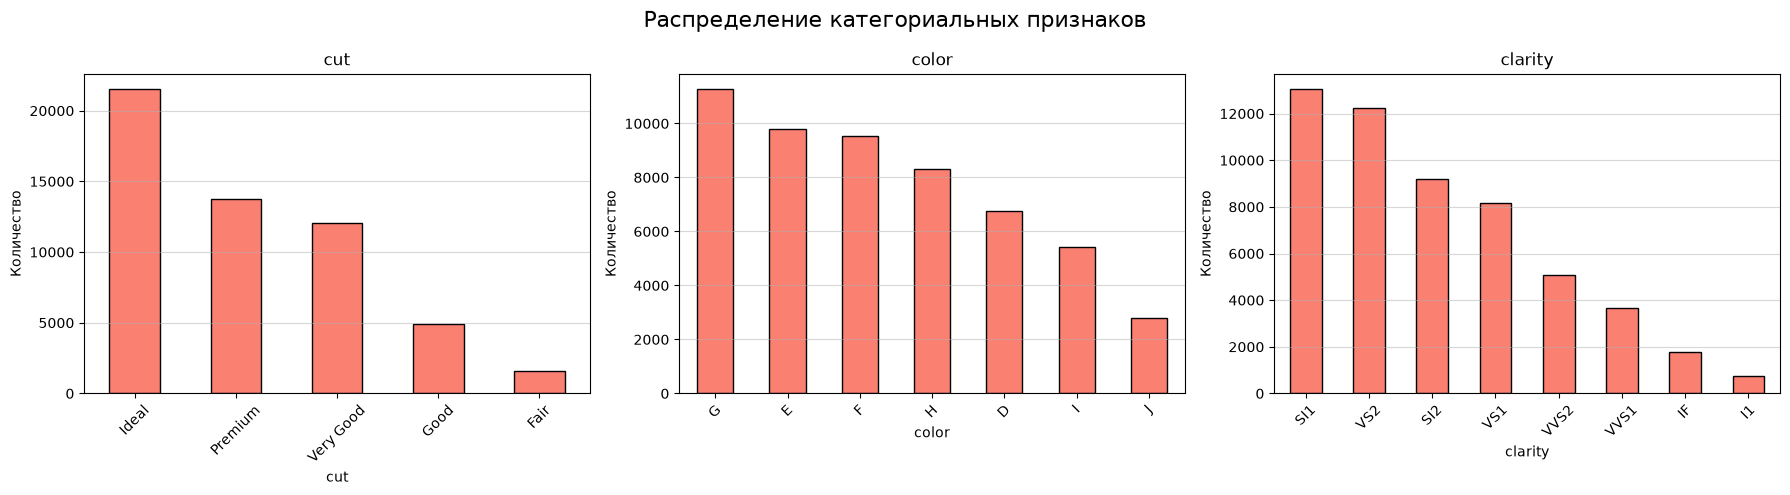

In [47]:
categorical_features = ['cut', 'color', 'clarity']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Распределение категориальных признаков', fontsize=16)

for i, col in enumerate(categorical_features):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Количество')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
df['cut'] = le.fit_transform(df['cut'])
df['color'] = le.fit_transform(df['color'])
df['clarity'] = le.fit_transform(df['clarity'])

display(df.head())

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


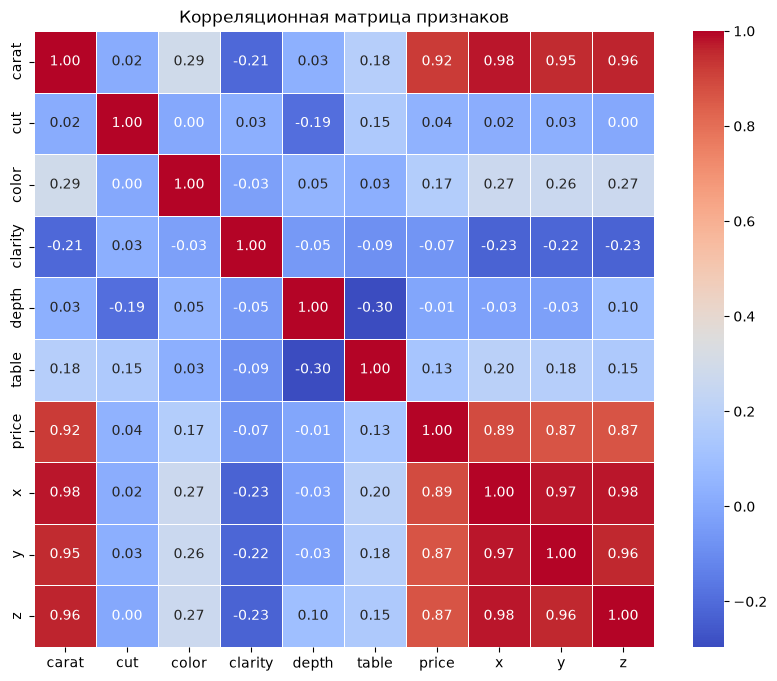

In [50]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.show()

In [ ]:
X_vif = df.drop('price', axis=1)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("Коэффициенты VIF (Variance Inflation Factor):")
display(vif_data.sort_values(by="VIF", ascending=False))

Коэффициенты VIF (Variance Inflation Factor):


,Feature,VIF
6,x,63.890788
8,z,29.935398
0,carat,24.777952
7,y,20.731517
4,depth,1.630528
5,table,1.160545
2,color,1.100392
3,clarity,1.067282
1,cut,1.052230
